In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


%matplotlib inline

pd.set_option("display.max_column", None)

In [3]:
df = pd.read_csv("../data/raw/insurance_claims.csv")

df.sample(5)

df.describe()

# df.info()

# df['region'].value_counts()


# df.duplicated().sum()

,age,bmi,alcohol_units_per_week,has_diabetes,has_hypertension,has_heart_disease,num_chronic_conditions,deductible_amount,num_dependents,annual_income,prior_claims_count,prior_claims_amount,policy_tenure_years,policy_start_year,region_cost_index,annual_premium
count,6040.000000,5738.000000,6040.000000,6040.000000,6040.000000,6040.000000,6040.000000,6040.000000,6040.000000,5798.000000,6040.000000,5616.000000,6040.000000,6040.000000,6040.000000,6040.000000
mean,41.117384,27.470512,3.439089,0.108609,0.307450,0.058940,0.475000,2103.228477,0.916556,59611.828206,0.861258,2121.883276,3.160364,2021.335265,1.069851,9408.777258
std,12.638213,5.371815,3.432408,0.311174,0.461476,0.235533,0.650604,1327.414024,1.187780,47380.385097,1.213965,4707.759760,1.352649,1.315334,0.112779,3214.113052
min,18.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,500.000000,0.000000,2000.000000,0.000000,0.000000,1.000000,2019.000000,0.950000,2397.710000
25%,32.000000,23.800000,1.000000,0.000000,0.000000,0.000000,0.000000,1000.000000,0.000000,27828.580000,0.000000,0.000000,2.100000,2020.000000,0.970000,6988.700000
50%,41.000000,27.400000,2.400000,0.000000,0.000000,0.000000,0.000000,2000.000000,0.000000,47505.990000,0.000000,0.000000,3.000000,2022.000000,1.020000,8896.450000
75%,50.000000,31.000000,4.800000,0.000000,1.000000,0.000000,1.000000,3000.000000,2.000000,77418.750000,1.000000,2487.915000,4.200000,2022.000000,1.180000,11369.850000
max,75.000000,44.900000,27.300000,1.000000,1.000000,1.000000,3.000000,5000.000000,4.000000,578694.130000,5.000000,100181.090000,6.000000,2023.000000,1.220000,23545.500000


## 1. Data Cleaning & Preprocessing

Based on our initial findings, we need to address:
1. **Duplicates:** Drop any duplicated rows.
2. **Missing Values:** Implement specific imputation strategies (MNAR vs MAR).
3. **Categorical Inconsistencies:** Standardize messy text data (`smoker`, `plan_tier`, `coverage_type`).
4. **Outliers:** Cap extreme values in alcohol consumption and BMI.


In [4]:
col_to_fix = ['smoker', 'plan_tier', 'coverage_type'] # smoker done
missing_val_col = ['bmi', 'annual_income', 'prior_claim_amounts']
col_to_drop = ['policy_id']


In [5]:
df_copy = df.copy()

#drop ids
df_copy = df_copy.drop(columns=col_to_drop, errors='ignore')

df_copy = df_copy.drop_duplicates()


def clean_smoker(x):
    if pd.isna(x): return x
    val = x.lower().strip()
    if val in ['yes']: return 'Yes'
    if val in ['no']: return 'No'
    if val in ['former', 'ex-smoker', 'ex smoker']: return 'Former'
    return val.title()

df_copy['smoker'] = df_copy['smoker'].apply(clean_smoker)

for col in ['plan_tier', 'coverage_type']:
    df_copy[col] = df_copy[col].str.strip().str.title()
    


In [6]:
df_copy['alcohol_units_per_week'].sample(10)
alcohol_99th = df_copy['alcohol_units_per_week'].quantile(0.99)
df_copy['alcohol_units_per_week'] = np.where(
    df_copy['alcohol_units_per_week'] > alcohol_99th, 
    alcohol_99th, 
    df_copy['alcohol_units_per_week']
)

In [7]:
df_copy['bmi'] = df_copy['bmi'].clip(lower=15, upper=55)

# Verify cleaning
print(f"Shape after cleaning: {df_copy.shape}")

Shape after cleaning: (6000, 22)


# alcohol units per week col
- based on the visuazliztion the histograms shows that it is positively skewed 

**strategy** 
- quantile, iqr, transform

<Axes: >

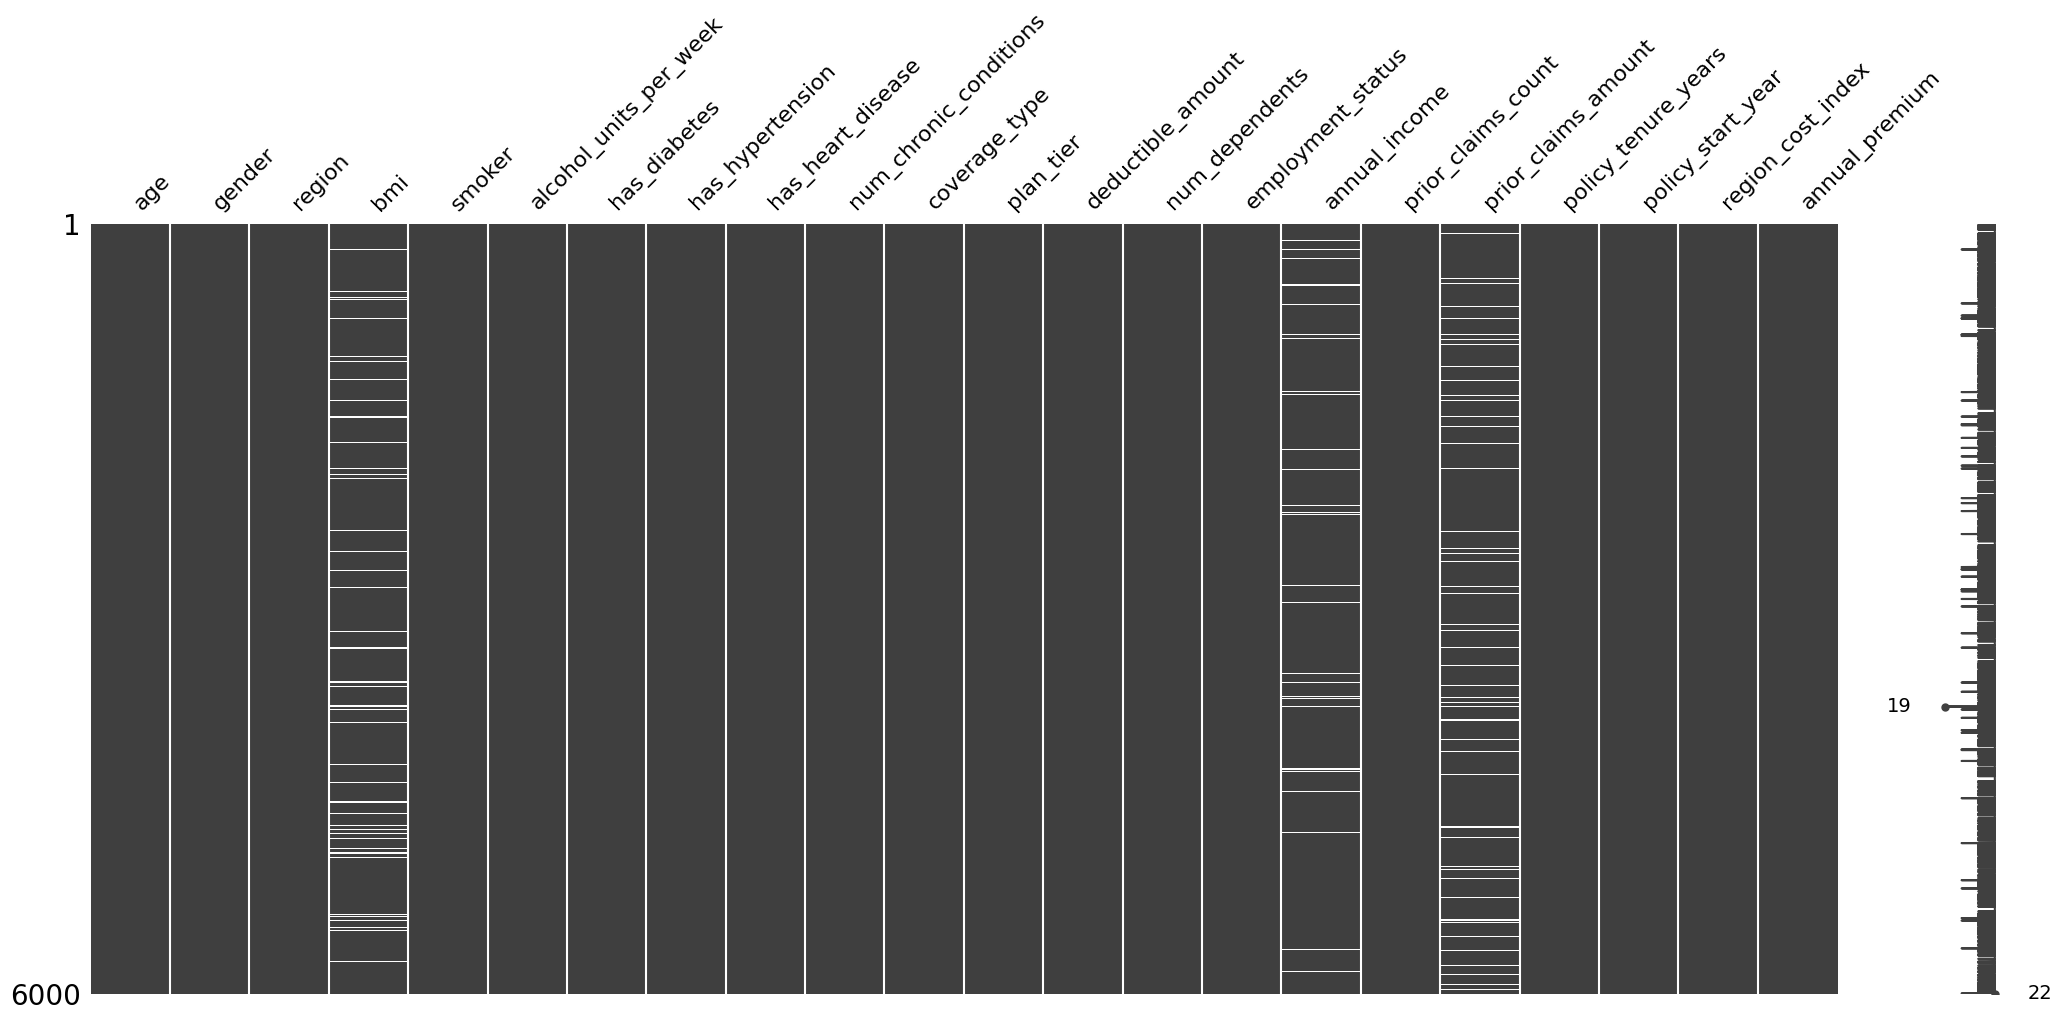

In [8]:
import missingno as msno
msno.matrix(df_copy)

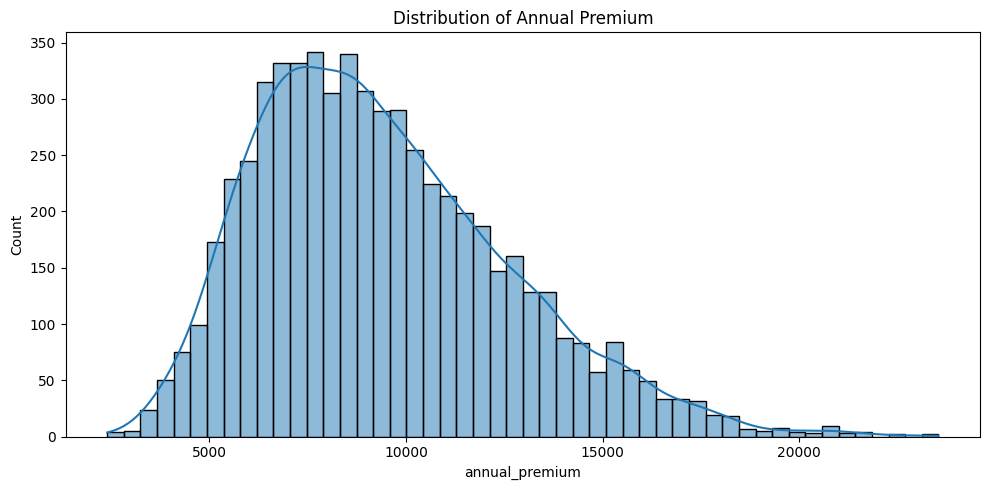

Premiums below $800: 0


In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df_copy['annual_premium'], bins=50, kde=True)
plt.title("Distribution of Annual Premium")
plt.tight_layout()
plt.savefig('../reports/figures/premium_distribution.png')
plt.show()

print(f"Premiums below $800: {len(df_copy[df_copy['annual_premium'] < 800])}")

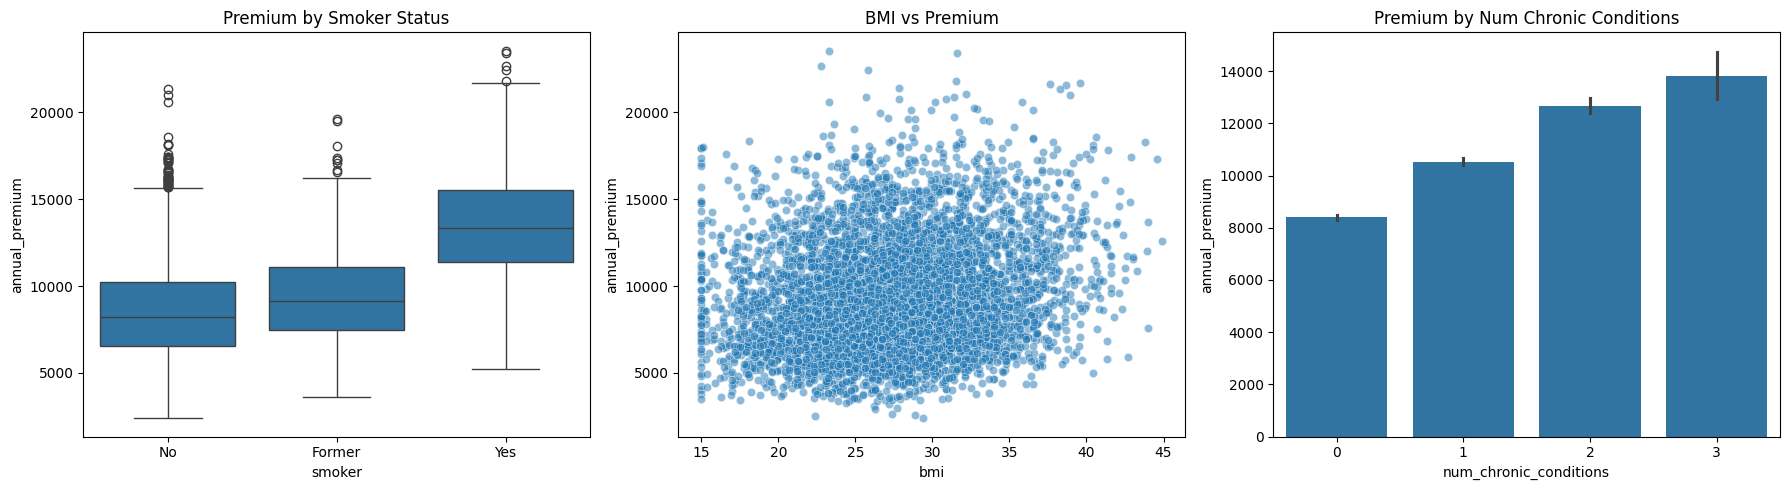

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_copy, x='smoker', y='annual_premium', ax=axes[0])
axes[0].set_title('Premium by Smoker Status')

sns.scatterplot(data=df_copy, x='bmi', y='annual_premium', alpha=0.5, ax=axes[1])
axes[1].set_title('BMI vs Premium')

sns.barplot(data=df_copy, x='num_chronic_conditions', y='annual_premium', ax=axes[2])
axes[2].set_title('Premium by Num Chronic Conditions')

plt.tight_layout()
plt.savefig('../reports/figures/premium_eda.png')
plt.show()

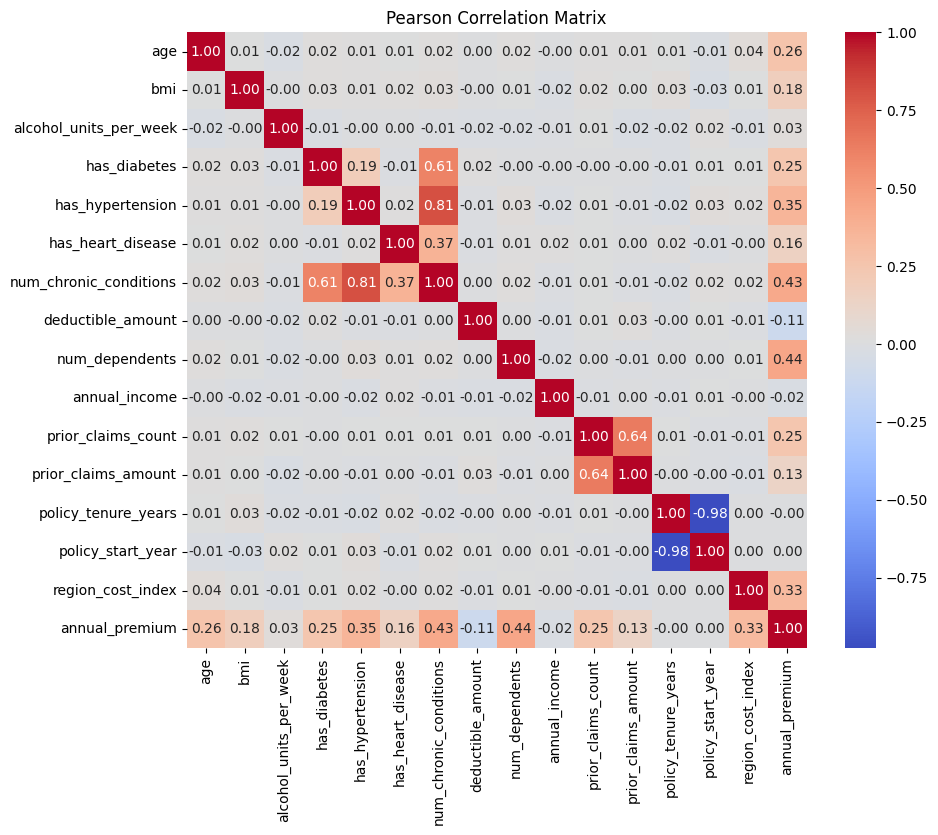

In [11]:
numeric_cols = df_copy.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Pearson Correlation Matrix")
plt.show()

  ---
  Data Overview
                                                                                                                            - Shape: 6,040 rows, 22 columns after cleaning
  - Duplicates: 40 duplicate rows found and removed                                                                       
  - Data types: Mix of numeric, categorical, and binary columns                                                           

  ---
  Data Cleaning & Preprocessing Strategies

  1. Categorical Standardization

  Columns: smoker, plan_tier, coverage_type

  Findings: Inconsistent capitalization (FORMER, bronze, GOLD) and varied terminology (ex-smoker, ex smoker)

  Strategy Applied:
  - Trimmed whitespace and applied .title() for uniform casing
  - smoker: Mapped yes/no - Yes/No, and variants like former, ex-smoker - Former

  2. Missing Value Handling

  Columns with missing values: bmi, annual_income, prior_claim_amounts

  Strategy: You're planning MNAR (Missing Not at Random) vs MAR (Missing at Random) imputation strategies but haven't     
  implemented them yet. The missingno matrix visualization helps identify patterns.

  3. Outlier Capping

  Columns: alcohol_units_per_week, bmi

  Findings:
  - Alcohol distribution is positively skewed (many zero/non-drinkers, few heavy drinkers up to 27 units/week)
  - BMI has extreme values (15.4 to 39+ in the sample)

  Strategy Applied:
  - Alcohol: 99th percentile capping to handle extreme values
  - BMI: Clipping at realistic bounds (15, 55) - values below 15 or above 55 are unreasonable for adults

  ---
  Key Observations

  Premium Distribution

  - No policies below $800 annual premium
  - Right-skewed distribution typical for insurance data

  Premium Correlates

  1. Smokers pay 2x more than non-smokers (visually evident in boxplot)
  2. BMI vs Premium: Positive but noisy relationship (higher BMI - higher risk - higher premium)
  3. Chronic conditions: More conditions → higher premiums (monotonic relationship)

  Correlation Matrix 

  - Likely finds strong correlation between:
    - Chronic conditions and age
    - Income and premium (higher income → more expensive plans)
    - Age and premium

  ---

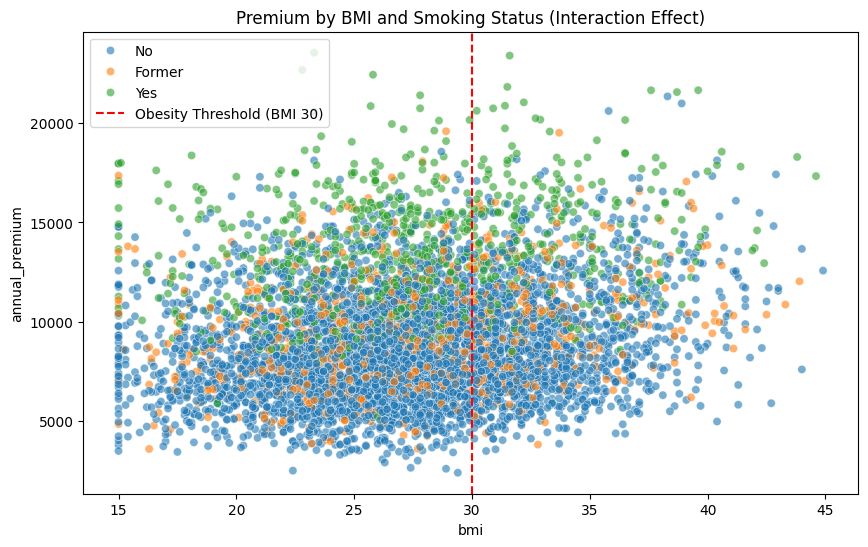

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='bmi', y='annual_premium', hue='smoker', alpha=0.6)
plt.title("Premium by BMI and Smoking Status (Interaction Effect)")
plt.axvline(30, color='red', linestyle='--', label='Obesity Threshold (BMI 30)')
plt.legend()
plt.show()

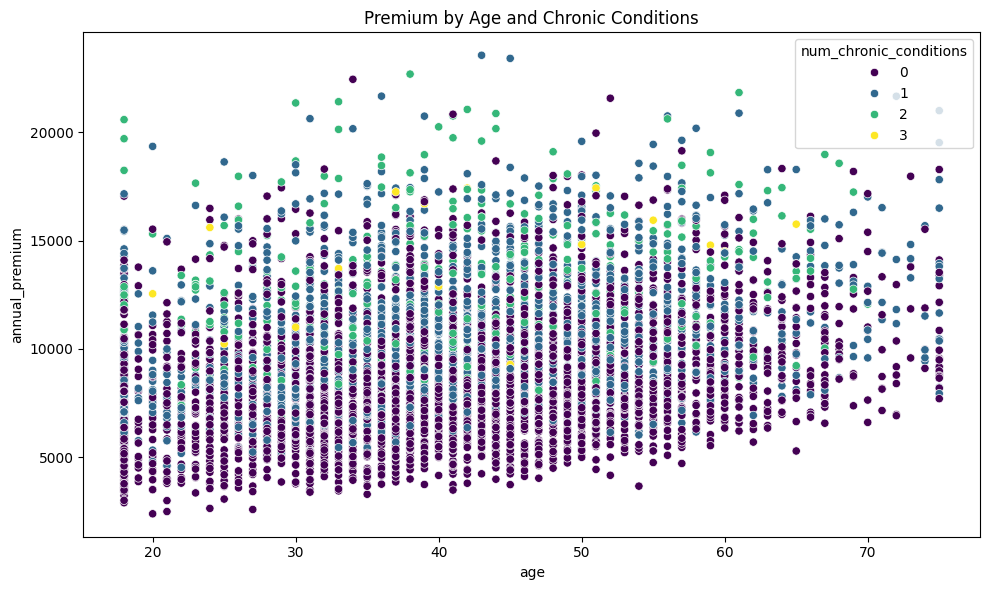

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='age', y='annual_premium', hue='num_chronic_conditions', palette='viridis')
plt.title("Premium by Age and Chronic Conditions")
plt.tight_layout()
plt.savefig('../reports/figures/premium_age_chronic.png', dpi=300)
plt.show()

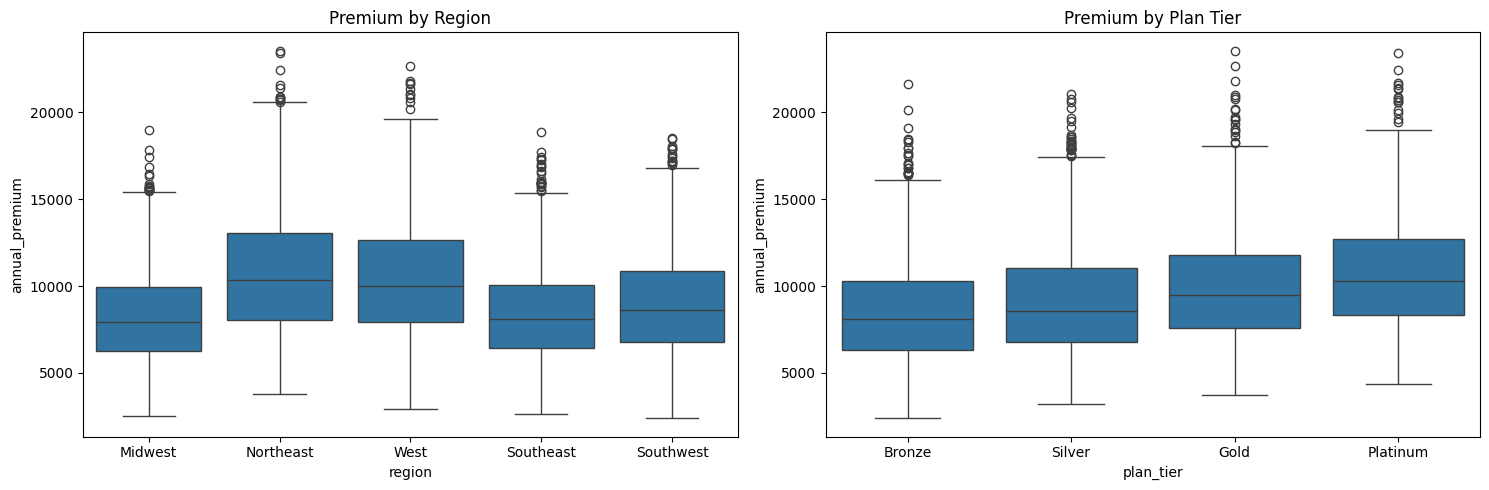

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df_copy, x='region', y='annual_premium', ax=axes[0])
axes[0].set_title('Premium by Region')

sns.boxplot(data=df_copy, x='plan_tier', y='annual_premium', 
            order=['Bronze', 'Silver', 'Gold', 'Platinum'], ax=axes[1])
axes[1].set_title('Premium by Plan Tier')

plt.tight_layout()
plt.savefig('../reports/figures/premium_region_plan_box.png', dpi=300)
plt.show()

In [ ]:
pd